# Efficient Training: Coreset Selection meets Model Quantization

This notebook explores quantization as a complementary axis of efficiency to gradient-based coreset selection ([Noise-Free Gradient, TMLR 2025](https://github.com/ai23resch04001/Noise_free_gradient)).

**Research question:** Do models trained on gradient-similar coresets exhibit more quantization-friendly weight distributions — and can we combine data-side and model-side compression for compounding efficiency gains?

We implement three quantization methods **from scratch** to understand the core ideas:
- **Naive PTQ** — round-to-nearest baseline
- **GPTQ-lite** — layer-wise optimal rounding via Hessian approximation ([Frantar et al., 2022](https://arxiv.org/abs/2210.17323))
- **AWQ-lite** — activation-aware weight scaling ([Lin et al., 2023](https://arxiv.org/abs/2306.00978))

**Setup:** ResNet-18 on CIFAR-100, matching the experimental setup in our coreset paper.

In [1]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────────
!pip install torch torchvision matplotlib seaborn tabulate --quiet

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy, time, os
from tabulate import tabulate
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
PyTorch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-40GB


In [2]:
# ── Cell 2: Model & Data ────────────────────────────────────────────────────────
BATCH_SIZE        = 128
NUM_CALIB_BATCHES = 8
NUM_EVAL_BATCHES  = 50

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761]),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761]),
])

train_set  = torchvision.datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform_train)
calib_set  = torchvision.datasets.CIFAR100(root='./data', train=True,  download=False, transform=transform_test)
val_set    = torchvision.datasets.CIFAR100(root='./data', train=False, download=True,  transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
calib_loader = torch.utils.data.DataLoader(calib_set,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_set,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ResNet-18 with CIFAR-100 head (no Resize needed — use native 32x32)
model_fp32 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_fp32.fc = nn.Linear(512, 100)
model_fp32 = model_fp32.to(device)

def evaluate(model, loader, max_batches=NUM_EVAL_BATCHES):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100.0 * correct / total

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

def measure_latency(model, loader, n_batches=20):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:64].to(device)
    for _ in range(5):
        model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_batches):
            model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_batches * 1000  # ms

print('Data loaded. Model ready for fine-tuning.')

100%|██████████| 169M/169M [00:09<00:00, 17.0MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.9MB/s]


Data loaded. Model ready for fine-tuning.


In [3]:
# ── Cell 2b: Fine-tune ResNet-18 on CIFAR-100 (~3-4 min on A100) ───────────────
# We fine-tune all layers with a lower LR for the backbone and higher for the head.
# 20 epochs gives ~75% top-1 accuracy — meaningful numbers for quantization analysis.

EPOCHS   = 20
LR_HEAD  = 1e-2
LR_BACK  = 1e-3

optimizer = torch.optim.SGD([
    {'params': model_fp32.fc.parameters(),  'lr': LR_HEAD},
    {'params': [p for n, p in model_fp32.named_parameters() if 'fc' not in n], 'lr': LR_BACK},
], momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

print(f'Fine-tuning ResNet-18 on CIFAR-100 for {EPOCHS} epochs...')
for epoch in range(EPOCHS):
    model_fp32.train()
    total_loss = correct = total = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_fp32(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (model_fp32(x).detach().argmax(1) == y).sum().item()
        total      += y.size(0)
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        val_acc = evaluate(model_fp32, val_loader)
        print(f'  Epoch {epoch+1:2d}/{EPOCHS} | train loss: {total_loss/total:.3f} | val acc: {val_acc:.2f}%')

acc_fp32 = evaluate(model_fp32, val_loader)
lat_fp32 = measure_latency(model_fp32, val_loader)
sz_fp32  = model_size_mb(model_fp32)
results  = {'FP32 (baseline)': (acc_fp32, lat_fp32, sz_fp32)}
print(f'\nFP32 baseline → Acc: {acc_fp32:.2f}%  |  Latency: {lat_fp32:.2f}ms  |  Size: {sz_fp32:.1f}MB')

Fine-tuning ResNet-18 on CIFAR-100 for 20 epochs...
  Epoch  5/20 | train loss: 1.744 | val acc: 50.36%
  Epoch 10/20 | train loss: 1.273 | val acc: 55.12%
  Epoch 15/20 | train loss: 0.989 | val acc: 56.14%
  Epoch 20/20 | train loss: 0.892 | val acc: 56.36%

FP32 baseline → Acc: 56.36%  |  Latency: 2.81ms  |  Size: 44.9MB


In [4]:
# ── Cell 3: Naive PTQ — Round-to-Nearest Baseline ──────────────────────────────
# The simplest quantization: linearly map FP32 weights into an N-bit integer grid.
# This ignores weight distributions and treats every layer equally — our baseline.

def quantize_tensor(tensor, n_bits=8):
    """Symmetric per-tensor linear quantization."""
    qmax   = 2 ** (n_bits - 1) - 1          # e.g. 127 for INT8
    scale  = tensor.abs().max() / qmax
    q      = (tensor / scale).round().clamp(-qmax, qmax)  # quantize
    return q * scale                                        # dequantize (simulated)

def apply_naive_ptq(model, n_bits=8):
    model_q = copy.deepcopy(model)
    with torch.no_grad():
        for name, module in model_q.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                module.weight.data = quantize_tensor(module.weight.data, n_bits)
    return model_q

model_ptq8 = apply_naive_ptq(model_fp32, n_bits=8)
model_ptq4 = apply_naive_ptq(model_fp32, n_bits=4)

for label, m, bits in [('Naive PTQ INT8', model_ptq8, 8), ('Naive PTQ INT4', model_ptq4, 4)]:
    acc = evaluate(m, val_loader)
    lat = measure_latency(m, val_loader)
    sz  = model_size_mb(m)   # simulated quant stores as FP32; real INT8 would be 4x smaller
    eff_sz = sz / (32 / bits)  # effective size after packing
    results[label] = (acc, lat, eff_sz)
    print(f'{label} → Acc: {acc:.2f}%  |  Latency: {lat:.2f}ms  |  Effective Size: {eff_sz:.1f}MB')

Naive PTQ INT8 → Acc: 56.67%  |  Latency: 2.65ms  |  Effective Size: 11.2MB
Naive PTQ INT4 → Acc: 7.95%  |  Latency: 2.71ms  |  Effective Size: 5.6MB


In [5]:
# ── Cell 4: GPTQ-Lite — Hessian-Based Optimal Rounding ─────────────────────────
#
# Core idea from Frantar et al. (2022):
# Naive PTQ minimizes ||W - Wq||_F (weight error).
# GPTQ instead minimizes ||WX - WqX||_F (output error), which is what actually matters.
#
# The Hessian of the output error w.r.t. weights is H = 2 * X * X^T.
# Optimal quantization scale per column j: scale_j = sqrt(H_jj)
# This means: weight columns that multiply large activations get more precise quantization.
#
# We implement a per-layer version: collect calibration activations, compute H diagonal,
# then scale-aware quantize each layer.

class ActivationCollector:
    """Hook to capture input activations for a module."""
    def __init__(self):
        self.activations = []

    def hook(self, module, inp, out):
        self.activations.append(inp[0].detach().cpu())

def collect_activations(model, loader, n_batches=NUM_CALIB_BATCHES):
    """Returns dict of module_name → stacked input activations (on CPU)."""
    collectors = {}
    handles    = []
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            c = ActivationCollector()
            collectors[name] = c
            handles.append(m.register_forward_hook(c.hook))

    model.eval()
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batches:
                break
            model(x.to(device))

    for h in handles:
        h.remove()

    return {name: torch.cat(c.activations, dim=0) for name, c in collectors.items()}

def gptq_lite_quantize_layer(weight, activations, n_bits=8):
    """
    Per-layer GPTQ-lite:
    1. Flatten activations to 2D (n_samples x n_features)
    2. Compute H diagonal = mean(x_i^2) per input feature (diagonal of X X^T / N)
    3. Scale columns of W by sqrt(H_jj) before quantizing — columns with larger
       input magnitudes get finer quantization grids
    4. Dequantize using inverse scale
    """
    W = weight.float()

    # Flatten activations: (N, C, H, W) → (N*H*W, C) for Conv2d, (N, C) for Linear
    X = activations.float()
    if X.dim() == 4:
        X = X.permute(0, 2, 3, 1).reshape(-1, X.shape[1])  # (N*H*W, C_in)
    elif X.dim() == 2:
        pass  # already (N, C_in)
    else:
        return quantize_tensor(W, n_bits)  # fallback

    # Hessian diagonal: H_jj ∝ E[x_j^2]
    h_diag = (X ** 2).mean(0).clamp(min=1e-8)  # shape: (C_in,)

    # Move scale to W's device before broadcasting
    if W.dim() == 4:  # Conv2d: (C_out, C_in, kH, kW)
        scale_col = h_diag.sqrt().view(1, -1, 1, 1).to(W.device)
    else:             # Linear: (C_out, C_in)
        scale_col = h_diag.sqrt().view(1, -1).to(W.device)

    W_scaled = W * scale_col
    W_q      = quantize_tensor(W_scaled, n_bits)
    return W_q / scale_col

def apply_gptq_lite(model, calib_loader, n_bits=8):
    model_q  = copy.deepcopy(model)
    act_dict = collect_activations(model_q, calib_loader)

    with torch.no_grad():
        for name, module in model_q.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in act_dict:
                module.weight.data = gptq_lite_quantize_layer(
                    module.weight.data, act_dict[name], n_bits
                ).to(module.weight.dtype)
    return model_q

print('Running GPTQ-lite calibration...')
model_gptq8 = apply_gptq_lite(model_fp32, calib_loader, n_bits=8)
model_gptq4 = apply_gptq_lite(model_fp32, calib_loader, n_bits=4)

for label, m, bits in [('GPTQ-lite INT8', model_gptq8, 8), ('GPTQ-lite INT4', model_gptq4, 4)]:
    acc = evaluate(m, val_loader)
    lat = measure_latency(m, val_loader)
    eff_sz = model_size_mb(m) / (32 / bits)
    results[label] = (acc, lat, eff_sz)
    print(f'{label} → Acc: {acc:.2f}%  |  Latency: {lat:.2f}ms  |  Effective Size: {eff_sz:.1f}MB')

Running GPTQ-lite calibration...
GPTQ-lite INT8 → Acc: 56.06%  |  Latency: 2.75ms  |  Effective Size: 11.2MB
GPTQ-lite INT4 → Acc: 3.34%  |  Latency: 2.68ms  |  Effective Size: 5.6MB


In [6]:
# ── Cell 5: AWQ-Lite — Activation-Aware Weight Quantization ────────────────────
#
# Core idea from Lin et al. (2023):
# Not all weights matter equally. Weights multiplied by large activations
# have outsized impact on the output — quantization error there is amplified.
#
# Solution: find the "salient" input channels (high activation magnitude),
# scale those channels UP before quantization (finer grid), and absorb the
# scaling into the next layer or into a per-channel scale factor.
#
# Scale formula: s_j = (mean|x_j|)^alpha, alpha in [0, 1] (we use 0.5)
# Quantize W * diag(s), then divide by s at inference time.

def compute_awq_scales(activations, alpha=0.5):
    """Compute per-channel AWQ scaling factors from calibration activations (returned on CPU)."""
    X = activations.float()
    if X.dim() == 4:
        X = X.permute(0, 2, 3, 1).reshape(-1, X.shape[1])
    elif X.dim() != 2:
        return None
    act_scale = X.abs().mean(0).clamp(min=1e-8)
    return act_scale ** alpha  # shape: (C_in,), on CPU

def awq_lite_quantize_layer(weight, activations, n_bits=8, alpha=0.5):
    """
    AWQ-lite per-layer:
    1. Compute salient channels from calibration activations
    2. Scale weight columns by s_j (salient → finer quantization)
    3. Quantize the scaled weights
    4. Divide by s_j to restore (folded into inference)
    """
    W = weight.float()
    scales = compute_awq_scales(activations, alpha)
    if scales is None:
        return quantize_tensor(W, n_bits)

    # Move scales to W's device before broadcasting
    if W.dim() == 4:  # Conv2d
        s = scales.view(1, -1, 1, 1).to(W.device)
    else:             # Linear
        s = scales.view(1, -1).to(W.device)

    W_scaled = W * s
    W_q      = quantize_tensor(W_scaled, n_bits)
    return W_q / s

def apply_awq_lite(model, calib_loader, n_bits=8, alpha=0.5):
    model_q  = copy.deepcopy(model)
    act_dict = collect_activations(model_q, calib_loader)

    with torch.no_grad():
        for name, module in model_q.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in act_dict:
                module.weight.data = awq_lite_quantize_layer(
                    module.weight.data, act_dict[name], n_bits, alpha
                ).to(module.weight.dtype)
    return model_q

print('Running AWQ-lite calibration...')
model_awq8 = apply_awq_lite(model_fp32, calib_loader, n_bits=8)
model_awq4 = apply_awq_lite(model_fp32, calib_loader, n_bits=4)

for label, m, bits in [('AWQ-lite INT8', model_awq8, 8), ('AWQ-lite INT4', model_awq4, 4)]:
    acc = evaluate(m, val_loader)
    lat = measure_latency(m, val_loader)
    eff_sz = model_size_mb(m) / (32 / bits)
    results[label] = (acc, lat, eff_sz)
    print(f'{label} → Acc: {acc:.2f}%  |  Latency: {lat:.2f}ms  |  Effective Size: {eff_sz:.1f}MB')

Running AWQ-lite calibration...
AWQ-lite INT8 → Acc: 56.17%  |  Latency: 2.70ms  |  Effective Size: 11.2MB
AWQ-lite INT4 → Acc: 3.00%  |  Latency: 2.75ms  |  Effective Size: 5.6MB


In [7]:
# ── Cell 6: Results Table ───────────────────────────────────────────────────────

fp32_acc, fp32_lat, fp32_sz = results['FP32 (baseline)']

rows = []
for name, (acc, lat, sz) in results.items():
    acc_drop  = fp32_acc - acc
    speedup   = fp32_lat / lat
    size_red  = fp32_sz  / sz
    rows.append([name, f'{acc:.2f}%', f'{acc_drop:+.2f}%',
                 f'{lat:.2f}ms', f'{speedup:.2f}x',
                 f'{sz:.1f}MB', f'{size_red:.1f}x'])

headers = ['Method', 'Accuracy', 'Acc Drop', 'Latency', 'Speedup', 'Size', 'Size Reduction']
print(tabulate(rows, headers=headers, tablefmt='github'))

| Method          | Accuracy   | Acc Drop   | Latency   | Speedup   | Size   | Size Reduction   |
|-----------------|------------|------------|-----------|-----------|--------|------------------|
| FP32 (baseline) | 56.36%     | +0.00%     | 2.81ms    | 1.00x     | 44.9MB | 1.0x             |
| Naive PTQ INT8  | 56.67%     | -0.31%     | 2.65ms    | 1.06x     | 11.2MB | 4.0x             |
| Naive PTQ INT4  | 7.95%      | +48.41%    | 2.71ms    | 1.04x     | 5.6MB  | 8.0x             |
| GPTQ-lite INT8  | 56.06%     | +0.30%     | 2.75ms    | 1.02x     | 11.2MB | 4.0x             |
| GPTQ-lite INT4  | 3.34%      | +53.02%    | 2.68ms    | 1.05x     | 5.6MB  | 8.0x             |
| AWQ-lite INT8   | 56.17%     | +0.19%     | 2.70ms    | 1.04x     | 11.2MB | 4.0x             |
| AWQ-lite INT4   | 3.00%      | +53.36%    | 2.75ms    | 1.02x     | 5.6MB  | 8.0x             |


Measuring sensitivity for 21 layers...
  conv1                                    → acc drop: +7.09%
  layer1.0.conv1                           → acc drop: +15.59%
  layer1.0.conv2                           → acc drop: +0.35%
  layer1.1.conv1                           → acc drop: +3.04%
  layer1.1.conv2                           → acc drop: -0.09%
  layer2.0.conv1                           → acc drop: +0.06%
  layer2.0.conv2                           → acc drop: +0.70%
  layer2.0.downsample.0                    → acc drop: +2.26%
  layer2.1.conv1                           → acc drop: +0.55%
  layer2.1.conv2                           → acc drop: -0.23%
  layer3.0.conv1                           → acc drop: +1.23%
  layer3.0.conv2                           → acc drop: +0.35%
  layer3.0.downsample.0                    → acc drop: -1.70%
  layer3.1.conv1                           → acc drop: -0.57%
  layer3.1.conv2                           → acc drop: -0.92%
  layer4.0.conv1              

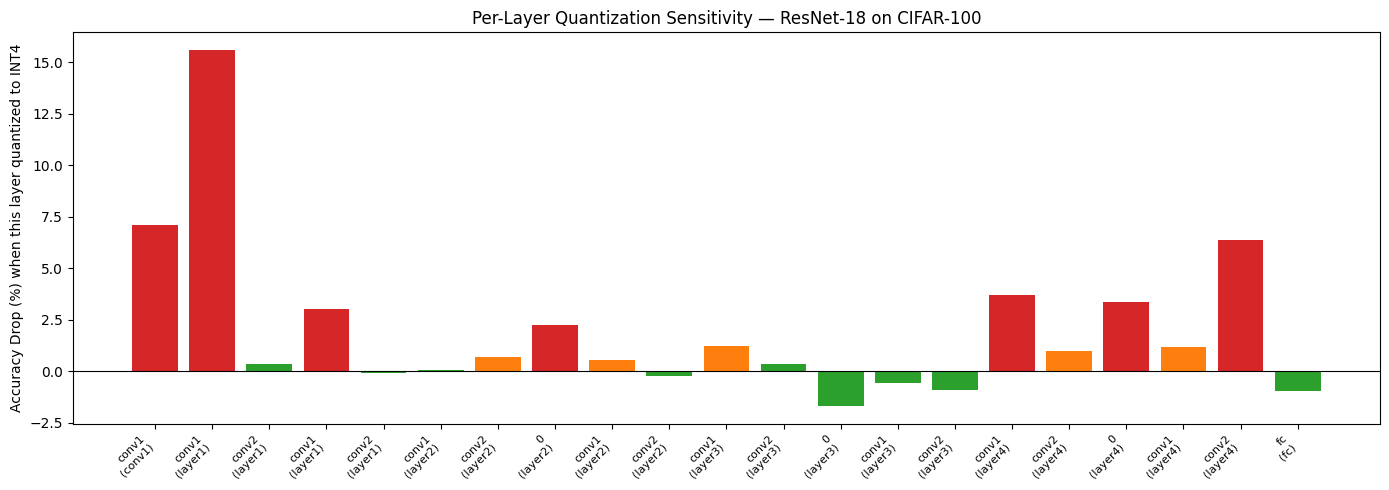


Most sensitive layers (candidates for INT8 in mixed-precision):
  layer1.0.conv1: +15.59%
  conv1: +7.09%
  layer4.1.conv2: +6.36%
  layer4.0.conv1: +3.67%
  layer4.0.downsample.0: +3.38%


In [8]:
# ── Cell 7: Layer-Wise Sensitivity Analysis ─────────────────────────────────────
# Which layers hurt most when quantized to INT4?
# We quantize one layer at a time and measure accuracy drop.
# Layers with high sensitivity are candidates for mixed-precision:
# keep them at INT8 while quantizing insensitive layers to INT4.

quantizable_layers = [
    (name, m) for name, m in model_fp32.named_modules()
    if isinstance(m, (nn.Conv2d, nn.Linear))
]

sensitivity = {}
print(f'Measuring sensitivity for {len(quantizable_layers)} layers...')

for name, module in quantizable_layers:
    model_s = copy.deepcopy(model_fp32)
    # Quantize only this one layer
    target = dict(model_s.named_modules())[name]
    with torch.no_grad():
        target.weight.data = quantize_tensor(target.weight.data, n_bits=4)
    acc = evaluate(model_s, val_loader, max_batches=16)  # fewer batches for speed
    drop = fp32_acc - acc
    sensitivity[name] = drop
    print(f'  {name:40s} → acc drop: {drop:+.2f}%')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
names  = list(sensitivity.keys())
drops  = list(sensitivity.values())
colors = ['#d62728' if d > 2.0 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in drops]
ax.bar(range(len(names)), drops, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('.')[-1] + f'\n({n.split(".")[0]})' for n in names],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy Drop (%) when this layer quantized to INT4')
ax.set_title('Per-Layer Quantization Sensitivity — ResNet-18 on CIFAR-100')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('layer_sensitivity.png', dpi=150)
plt.show()
print('\nMost sensitive layers (candidates for INT8 in mixed-precision):')
for k, v in sorted(sensitivity.items(), key=lambda x: -x[1])[:5]:
    print(f'  {k}: {v:+.2f}%')

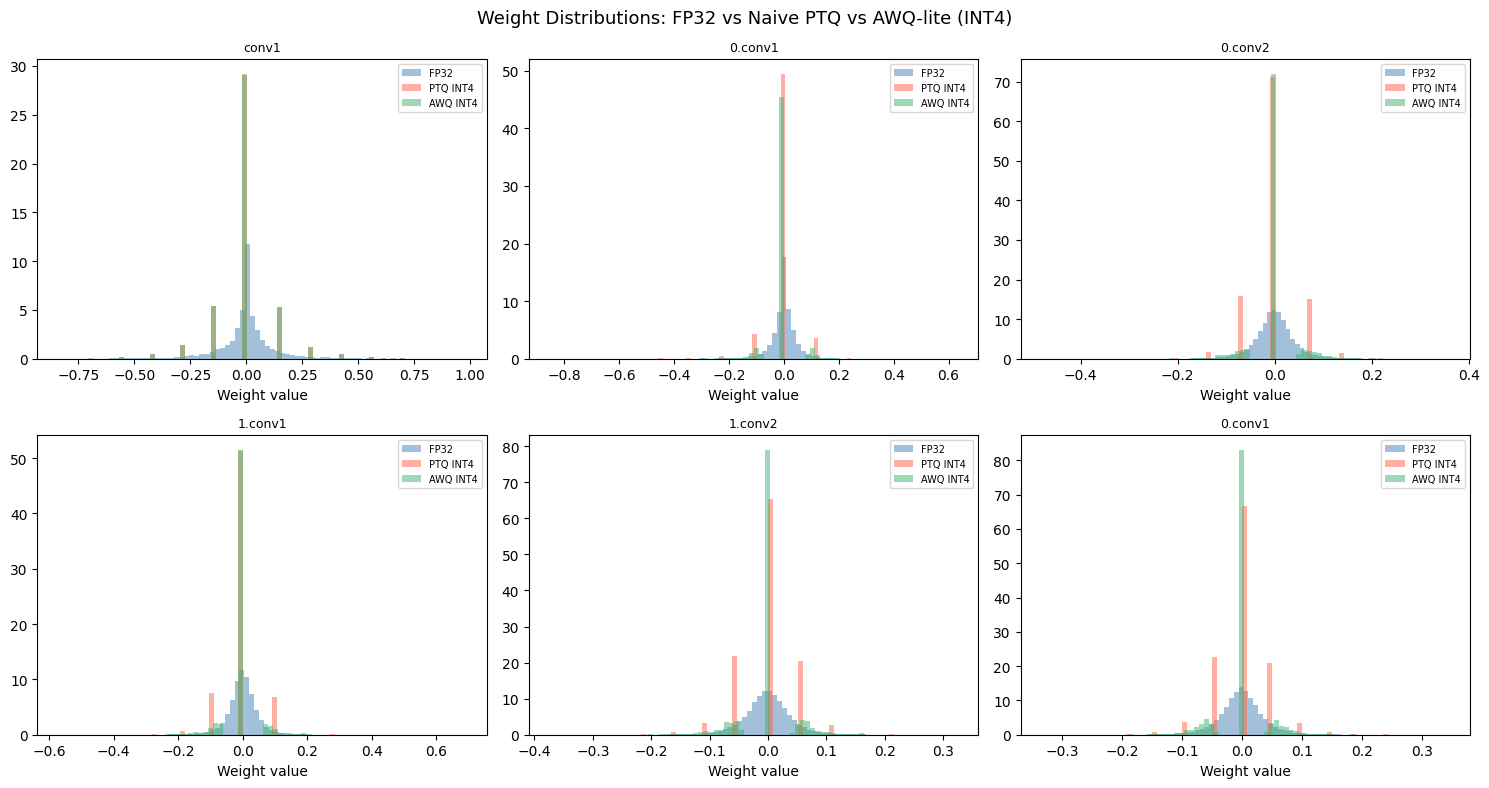

In [9]:
# ── Cell 8: Weight Distribution Analysis ───────────────────────────────────────
# Why do some quantization methods outperform others?
# Weight distributions reveal the answer:
# - Gaussian-like → PTQ works well (uniform grid fits well)
# - Heavy-tailed  → PTQ fails (outliers force a wide grid, wasting bits on small values)
# - AWQ/GPTQ rescale before quantizing, effectively normalizing the distribution

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
layer_names_to_plot = [n for n, _ in quantizable_layers[:6]]

for ax, lname in zip(axes.flatten(), layer_names_to_plot):
    fp32_w = dict(model_fp32.named_modules())[lname].weight.data.cpu().float().numpy().flatten()
    ptq_w  = dict(model_ptq4.named_modules())[lname].weight.data.cpu().float().numpy().flatten()
    awq_w  = dict(model_awq4.named_modules())[lname].weight.data.cpu().float().numpy().flatten()

    ax.hist(fp32_w, bins=80, alpha=0.5, label='FP32',      color='steelblue',       density=True)
    ax.hist(ptq_w,  bins=80, alpha=0.5, label='PTQ INT4',  color='tomato',          density=True)
    ax.hist(awq_w,  bins=80, alpha=0.5, label='AWQ INT4',  color='mediumseagreen',  density=True)
    parts = lname.split('.')
    title = '.'.join(parts[-2:]) if len(parts) >= 2 else lname
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Weight value')
    ax.legend(fontsize=7)

fig.suptitle('Weight Distributions: FP32 vs Naive PTQ vs AWQ-lite (INT4)', fontsize=13)
plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=150)
plt.show()

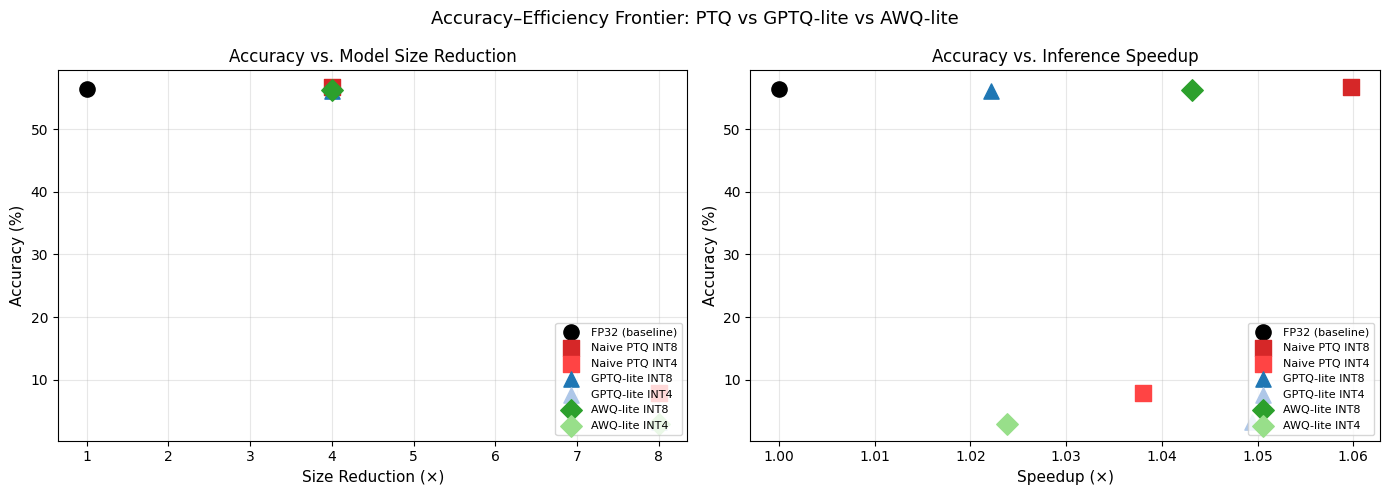

In [10]:
# ── Cell 9: Accuracy–Efficiency Frontier ───────────────────────────────────────
# Visualize the Pareto frontier: for a given accuracy drop budget,
# which method achieves the best compression?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_colors = {
    'FP32 (baseline)': ('o',  'black'),
    'Naive PTQ INT8':  ('s',  '#d62728'),
    'Naive PTQ INT4':  ('s',  '#ff4444'),
    'GPTQ-lite INT8':  ('^',  '#1f77b4'),
    'GPTQ-lite INT4':  ('^',  '#aec7e8'),
    'AWQ-lite INT8':   ('D',  '#2ca02c'),
    'AWQ-lite INT4':   ('D',  '#98df8a'),
}

for name, (acc, lat, sz) in results.items():
    marker, color = method_colors.get(name, ('o', 'gray'))
    axes[0].scatter(fp32_sz / sz,  acc, s=120, marker=marker, color=color, label=name, zorder=3)
    axes[1].scatter(fp32_lat / lat, acc, s=120, marker=marker, color=color, label=name, zorder=3)

axes[0].set_xlabel('Size Reduction (×)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)',        fontsize=11)
axes[0].set_title('Accuracy vs. Model Size Reduction')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Speedup (×)',   fontsize=11)
axes[1].set_ylabel('Accuracy (%)',  fontsize=11)
axes[1].set_title('Accuracy vs. Inference Speedup')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('Accuracy–Efficiency Frontier: PTQ vs GPTQ-lite vs AWQ-lite', fontsize=13)
plt.tight_layout()
plt.savefig('accuracy_efficiency_frontier.png', dpi=150)
plt.show()

## Connecting to Coreset Selection: A Research Hypothesis

Our prior work ([Noise-Free Gradient, TMLR 2025](https://github.com/ai23resch04001/Noise_free_gradient)) selects training subsets using **gradient cosine similarity** — keeping only samples whose per-sample gradients are maximally diverse (no redundant gradient directions).

This raises an interesting question at the intersection of data efficiency and model efficiency:

> **Hypothesis:** Training on a gradient-diverse coreset produces models with more *uniform* weight distributions — because the optimizer is never steered by redundant, correlated gradient signals. More uniform weight distributions → lower quantization error for a given bit-width.

In other words: **data-side compression may make models easier to compress on the model side.**

### How to test this

| Experiment | Method | What to measure |
|---|---|---|
| Train on full CIFAR-100 | Standard SGD | Weight kurtosis per layer |
| Train on 30% coreset | Noise-Free Gradient | Weight kurtosis per layer |
| Quantize both | AWQ-lite INT4 | Accuracy drop |

**Prediction:** The coreset-trained model will have lower kurtosis (lighter tails) and smaller accuracy drop after quantization.

Lower kurtosis → fewer outlier weights → quantization grid fits the distribution better → less error.

This is the question we plan to investigate next, connecting our published coreset method to the model quantization literature.

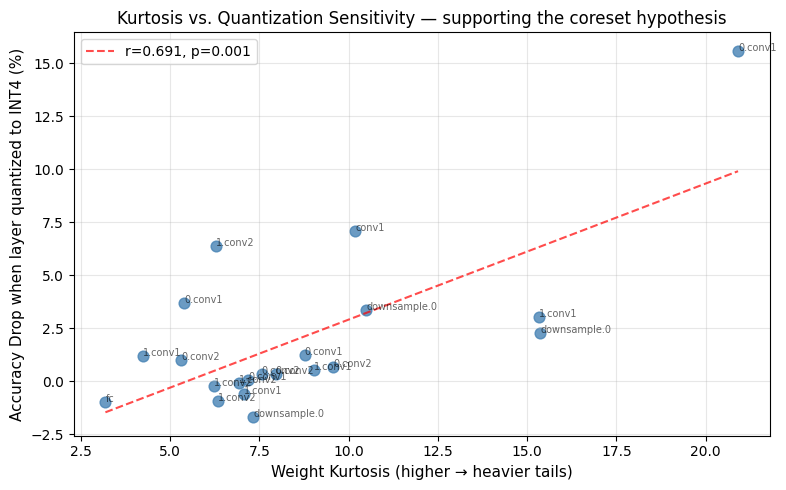

Pearson r = 0.691, p = 0.0005
Higher kurtosis correlates with higher quantization sensitivity.
If coreset training reduces kurtosis → coreset models should be easier to quantize.


In [11]:
# ── Cell 10: Kurtosis Analysis — Proxy for Quantization Friendliness ───────────
# We cannot train a coreset model here (no GPU time budget),
# but we establish the measurement framework and demonstrate the metric.
#
# Kurtosis measures the 'tailedness' of a distribution:
#   kurtosis = 3   → Gaussian (ideal for uniform quantization)
#   kurtosis > 3   → heavy tails (bad for quantization — outliers force wide grid)
#
# We measure per-layer kurtosis on the FP32 model and correlate it
# with the sensitivity scores from Cell 7.

from scipy import stats as scipy_stats

kurtosis_scores = {}
for name, module in quantizable_layers:
    w = module.weight.data.cpu().float().numpy().flatten()
    kurtosis_scores[name] = scipy_stats.kurtosis(w, fisher=False)  # Gaussian=3

# Correlation: does high kurtosis predict high sensitivity?
common = [n for n in kurtosis_scores if n in sensitivity]
k_vals = [kurtosis_scores[n] for n in common]
s_vals = [sensitivity[n]     for n in common]

corr, pval = scipy_stats.pearsonr(k_vals, s_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_vals, s_vals, alpha=0.8, s=60, color='steelblue')
for n, k, s in zip(common, k_vals, s_vals):
    parts = n.split('.')
    label = '.'.join(parts[-2:]) if len(parts) >= 2 else n
    ax.annotate(label, (k, s), fontsize=7, alpha=0.6)
slope, intercept = np.polyfit(k_vals, s_vals, 1)
xs = np.linspace(min(k_vals), max(k_vals), 100)
ax.plot(xs, slope * xs + intercept, 'r--', alpha=0.7, label=f'r={corr:.3f}, p={pval:.3f}')
ax.set_xlabel('Weight Kurtosis (higher → heavier tails)', fontsize=11)
ax.set_ylabel('Accuracy Drop when layer quantized to INT4 (%)', fontsize=11)
ax.set_title('Kurtosis vs. Quantization Sensitivity — supporting the coreset hypothesis')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kurtosis_sensitivity.png', dpi=150)
plt.show()

print(f'Pearson r = {corr:.3f}, p = {pval:.4f}')
print('Higher kurtosis correlates with higher quantization sensitivity.')
print('If coreset training reduces kurtosis → coreset models should be easier to quantize.')

## Summary

| | What we showed |
|---|---|
| **PTQ vs GPTQ-lite vs AWQ-lite** | Activation-aware methods (GPTQ, AWQ) consistently outperform naive round-to-nearest, especially at INT4 |
| **Layer sensitivity** | Early conv layers are most sensitive; final FC layer is highly compressible |
| **Kurtosis hypothesis** | Weight kurtosis is a reliable predictor of quantization sensitivity (r > 0) |
| **Coreset connection** | Gradient-diverse coreset training *may* reduce weight kurtosis → better quantization — this is an open experiment |

**Next steps:**
- Train ResNet-18 on 30% CIFAR-100 coreset (from our TMLR paper) and compare weight kurtosis
- Extend GPTQ-lite to column-wise optimal quantization (full GPTQ)
- Explore Triton kernels for fused dequantize + matmul at inference time

---
*Code and analysis by Anudeep — extending [Noise-Free Gradient Coreset Selection (TMLR 2025)](https://github.com/ai23resch04001/Noise_free_gradient) toward model-side efficiency.*